# RLHF Results

Run all cells to generate paper figures and full results for all scenarios.

In [1]:
import json
import os
import re
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# ============================================
# Configuration
# ============================================
SCRATCH_DIR = os.environ.get("SCRATCH_DIR", "/workspace-vast/pbb/scratch")
out_dir = f"{SCRATCH_DIR}/Dr.Post-Training/RLHF"
config_dir = './train/configs/toxicity'
save_dir = './figures'
os.makedirs(save_dir, exist_ok=True)

def load_yaml_config(config_dir, method_name=None):
    """Load defaults.yaml, optionally overlaid with method config."""
    cfg = {}
    defaults_path = os.path.join(config_dir, 'defaults.yaml')
    if os.path.exists(defaults_path):
        with open(defaults_path) as f:
            cfg.update(yaml.safe_load(f))
    if method_name:
        method_path = os.path.join(config_dir, f'{method_name}.yaml')
        if os.path.exists(method_path):
            with open(method_path) as f:
                method_cfg = yaml.safe_load(f)
                if method_cfg:
                    cfg.update(method_cfg)
    return cfg

# Load shared defaults
shared_config = load_yaml_config(config_dir)
task = shared_config.get('task', 'toxicity')
model = os.path.basename(shared_config.get('model', 'gpt-neo-2.7B'))
print(f"Loaded config from {config_dir}/defaults.yaml")
print(f"Task: {task}, Model: {model}")

# Methods
# TargetOnly = plain PPO on the n_val held-out prompts only (held-out scenarios only).
ALL_METHODS = ['FullTraining-LoRA', 'TargetOnly-LoRA', 'IIF-LoRA', 'LayerWiseSubset-LoRA', 'GlobalSubset-LoRA']

LEGEND_NAMES = {
    'FullTraining-LoRA': 'Full-Training',
    'TargetOnly-LoRA': 'Target-Only',
    'IIF-LoRA': 'IIF',
    'LayerWiseSubset-LoRA': 'Layer-Wise Subset',
    'GlobalSubset-LoRA': 'Global Subset',
}

METHOD_COLORS = {
    'FullTraining-LoRA': 'black',
    'TargetOnly-LoRA': 'gray',
    'IIF-LoRA': 'blue',
    'LayerWiseSubset-LoRA': 'red',
    'GlobalSubset-LoRA': 'green',
}

# All scenarios. val_loss_type uses the canonical --val_loss_type names
# (reward | token-pg | train-loss); run dirs use the short forms below.
#   reward     : -E[normalize(R) * log pi(y|x)]              (sequence-level)
#   token-pg   : -sum_t A_t log pi(y_t|.)                    (token-level PG = PPO surrogate at ratio 1)
#   train-loss : clipped PPO surrogate + vf_coef * value loss (the training objective)
# n_val = 0 -> self-referencing target (training rollouts); n_val > 0 -> held-out prompts.
SCENARIOS = {
    'self-ref / reward':     {'n_val': 0,    'val_loss_type': 'reward'},
    'self-ref / token-pg':   {'n_val': 0,    'val_loss_type': 'token-pg'},
    'self-ref / train-loss': {'n_val': 0,    'val_loss_type': 'train-loss'},
    'held-out / reward':     {'n_val': 1024, 'val_loss_type': 'reward'},
    'held-out / token-pg':   {'n_val': 1024, 'val_loss_type': 'token-pg'},
    'held-out / train-loss': {'n_val': 1024, 'val_loss_type': 'train-loss'},
}

# Must match the case statement in train/train.sh.
VAL_TYPE_SHORT = {'reward': 'rew', 'token-pg': 'tpg', 'train-loss': 'tloss'}

print(f"Scenarios: {len(SCENARIOS)}")
print(f"Methods: {', '.join(ALL_METHODS)}")

Loaded config from ./train/configs/toxicity/defaults.yaml
Task: toxicity, Model: gpt-neo-2.7B
Scenarios: 6
Methods: FullTraining-LoRA, TargetOnly-LoRA, IIF-LoRA, LayerWiseSubset-LoRA, GlobalSubset-LoRA


## Helper Functions & Load All Data

In [3]:
# ============================================
# Helper functions (parameterized by scenario)
# ============================================

_config_cache = {}

def _method_config(method_name):
    """Load merged config (defaults + method overrides) from YAML."""
    if method_name not in _config_cache:
        _config_cache[method_name] = load_yaml_config(config_dir, method_name)
    return _config_cache[method_name]

def _lr(method_name):
    # train.sh writes the YAML value verbatim into the run name (e.g. "1e-5").
    cfg = _method_config(method_name)
    return str(cfg.get('learning_rate', '1e-5'))

def _kl(method_name):
    cfg = _method_config(method_name)
    return float(cfg.get('init_kl_coef', 0.02))

def _dir_name(method_name, seed, scfg):
    """Build directory name for a method + scenario + seed."""
    cfg = _method_config(method_name)
    method, finetuning = method_name.split('-', 1)
    lr = _lr(method_name)
    kl_coef = _kl(method_name)
    # FullTraining never uses a target: train.sh files it under v0-rew for every scenario.
    if method == 'FullTraining':
        scfg = {'n_val': 0, 'val_loss_type': 'reward'}
    # TargetOnly trains on the n_val held-out prompts: only meaningful for held-out scenarios.
    if method == 'TargetOnly':
        if scfg['n_val'] == 0:
            return '__no_target_only_for_self_ref__'
        scfg = {'n_val': scfg['n_val'], 'val_loss_type': 'reward'}
    vlt_short = VAL_TYPE_SHORT[scfg['val_loss_type']]
    val_str = f"v{scfg['n_val']}-{vlt_short}"
    if scfg['n_val'] > 0:
        val_str = f"{val_str}-b{cfg.get('val_batch_size', 256)}"
    return (f"{task}-{model}-{method}-{finetuning}"
            f"-lr{lr}-b{cfg.get('batch_size', 256)}-{val_str}"
            f"-pe{cfg.get('ppo_epochs', 4)}-mb{cfg.get('mini_batch_size', 4)}"
            f"-kl{kl_coef}-s{seed}")

def _discover_seeds(method_name, scfg):
    pattern = _dir_name(method_name, '*', scfg)
    seeds = []
    for p in glob(f"{out_dir}/{pattern}"):
        m = re.search(r'-s(\d+)$', Path(p).name)
        if m:
            seeds.append(int(m.group(1)))
    return sorted(seeds)

def _load_history(path):
    with open(path, 'r') as f:
        h = json.load(f)
    n = len(h.get('reward', []))
    return {
        'steps': np.arange(n),
        'reward_mean': np.array(h.get('reward', [])),
        'kl': np.array(h.get('kl', [])),
        'batch_toxicity': np.array(h.get('toxicity_prob', [])),
        'eval_toxicity_steps': np.array(h.get('full_eval_steps', [])),
        'eval_toxicity': np.array(h.get('full_eval_toxicity_prob', [])),
    }

def _load_log(path):
    steps, rewards, kls, btox = [], [], [], []
    etox, etox_steps = [], []
    with open(path, 'r') as f:
        for line in f:
            if 'Step ' in line and 'Eval step' not in line:
                try:
                    sm = re.search(r'Step (\d+):', line)
                    if not sm: continue
                    step = int(sm.group(1))
                    metrics = None
                    if '{' in line:
                        try:
                            metrics = json.loads(line[line.index('{'):line.rindex('}')+1].replace("'", '"'))
                        except: pass
                    if metrics is None:
                        metrics = {}
                        for k, v in re.findall(r'(\w+)=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)', line):
                            val = float(v)
                            if k == 'reward': metrics['reward/mean'] = val
                            elif k == 'kl': metrics['objective/kl'] = val
                            elif k == 'tox': metrics['eval/toxicity_prob'] = val
                    if metrics:
                        steps.append(step)
                        rewards.append(metrics.get('reward/mean', 0))
                        kls.append(metrics.get('objective/kl', 0))
                        btox.append(metrics.get('eval/toxicity_prob', 0))
                except: continue
            elif '[Eval step' in line and 'toxicity:' in line:
                try:
                    m = re.search(r'\[Eval step (\d+)\] toxicity: ([\d.]+)', line)
                    if m: etox_steps.append(int(m.group(1))); etox.append(float(m.group(2)))
                except: continue
    return {
        'steps': np.array(steps), 'reward_mean': np.array(rewards),
        'kl': np.array(kls), 'batch_toxicity': np.array(btox),
        'eval_toxicity_steps': np.array(etox_steps), 'eval_toxicity': np.array(etox),
    }

def _load_exp(exp_path):
    for fname, loader, src in [('training_history.json', _load_history, 'history'), ('train.log', _load_log, 'log')]:
        p = f"{exp_path}/{fname}"
        if Path(p).exists():
            try: return loader(p), src
            except Exception as e: print(f"  Warning: {p}: {e}")
    return None, None

def load_method(method_name, scfg):
    """Load and aggregate results across seeds for a method + scenario."""
    seeds = _discover_seeds(method_name, scfg)
    if not seeds: return None
    all_res, valid_seeds = [], []
    for seed in seeds:
        result, _ = _load_exp(f"{out_dir}/{_dir_name(method_name, seed, scfg)}")
        if result is not None and len(result['steps']) > 0:
            all_res.append(result); valid_seeds.append(seed)
    if not all_res: return None
    n_seeds = len(valid_seeds)
    se = np.sqrt(n_seeds)  # standard error denominator
    ml = min(len(r['steps']) for r in all_res)
    def _s(k): return np.stack([r[k][:ml] for r in all_res])
    reward, kl, btox = _s('reward_mean'), _s('kl'), _s('batch_toxicity')
    eml = min(len(r['eval_toxicity']) for r in all_res) if all(len(r['eval_toxicity']) > 0 for r in all_res) else 0
    if eml > 0:
        etox = np.stack([r['eval_toxicity'][:eml] for r in all_res])
        etox_steps = all_res[0]['eval_toxicity_steps'][:eml]
    else:
        etox, etox_steps = np.array([]).reshape(0,0), np.array([])
    return {
        'steps': all_res[0]['steps'][:ml],
        'reward_mean_mean': np.mean(reward, 0), 'reward_mean_std': np.std(reward, 0) / se,
        'kl_mean': np.mean(kl, 0), 'kl_std': np.std(kl, 0) / se,
        'batch_toxicity_mean': np.mean(btox, 0), 'batch_toxicity_std': np.std(btox, 0) / se,
        'eval_toxicity_steps': etox_steps,
        'eval_toxicity_mean': np.mean(etox, 0) if eml > 0 else np.array([]),
        'eval_toxicity_std': np.std(etox, 0) / se if eml > 0 else np.array([]),
        'n_seeds': n_seeds, 'seeds': valid_seeds,
    }

# ============================================
# Load ALL scenarios upfront
# ============================================
# all_data[scenario_name][method_name] = {...}
all_data = {}

for sname, scfg in SCENARIOS.items():
    print(f"\n{'='*60}")
    print(f"Loading: {sname}")
    print(f"{'='*60}")

    sdata = {}
    for method_name in ALL_METHODS:
        data = load_method(method_name, scfg)
        if data:
            sdata[method_name] = data
            print(f"  + {method_name}: {data['n_seeds']} seeds, {len(data['steps'])} points")
        else:
            pattern = _dir_name(method_name, '*', scfg)
            print(f"  - {method_name}: Not found ({pattern})")

    all_data[sname] = sdata
    print(f"  Loaded {len(sdata)}/{len(ALL_METHODS)} methods")

print(f"\n{'='*60}")
print(f"All {len(all_data)} scenarios loaded.")
print(f"{'='*60}")


Loading: self-ref / reward
  + FullTraining-LoRA: 5 seeds, 111 points
  - TargetOnly-LoRA: Not found (__no_target_only_for_self_ref__)
  + IIF-LoRA: 5 seeds, 111 points
  + LayerWiseSubset-LoRA: 5 seeds, 111 points
  + GlobalSubset-LoRA: 5 seeds, 111 points
  Loaded 4/5 methods

Loading: self-ref / token-pg
  + FullTraining-LoRA: 5 seeds, 111 points
  - TargetOnly-LoRA: Not found (__no_target_only_for_self_ref__)
  + IIF-LoRA: 5 seeds, 111 points
  + LayerWiseSubset-LoRA: 5 seeds, 111 points
  + GlobalSubset-LoRA: 5 seeds, 111 points
  Loaded 4/5 methods

Loading: self-ref / train-loss
  + FullTraining-LoRA: 5 seeds, 111 points
  - TargetOnly-LoRA: Not found (__no_target_only_for_self_ref__)
  + IIF-LoRA: 5 seeds, 111 points
  + LayerWiseSubset-LoRA: 5 seeds, 111 points
  + GlobalSubset-LoRA: 5 seeds, 111 points
  Loaded 4/5 methods

Loading: held-out / reward
  + FullTraining-LoRA: 5 seeds, 111 points
  + TargetOnly-LoRA: 5 seeds, 111 points
  + IIF-LoRA: 5 seeds, 111 points
  + Laye

## Paper Figures: Reward + Eval Toxicity (per scenario)

Two publication-ready plots per scenario: Reward vs Round, Eval Toxicity vs Round.


  self-ref / reward
    [reward] + FullTraining-LoRA: 5 seeds, final=4.5739
    [reward] + IIF-LoRA: 5 seeds, final=4.6659
    [reward] + LayerWiseSubset-LoRA: 5 seeds, final=4.6776
    [reward] + GlobalSubset-LoRA: 5 seeds, final=4.6869
    [eval_tox] + FullTraining-LoRA: 5 seeds, final=0.0746
    [eval_tox] + IIF-LoRA: 5 seeds, final=0.0226
    [eval_tox] + LayerWiseSubset-LoRA: 5 seeds, final=0.0086
    [eval_tox] + GlobalSubset-LoRA: 5 seeds, final=0.0094
    -> Saved: ./figures/self-ref_reward.pdf


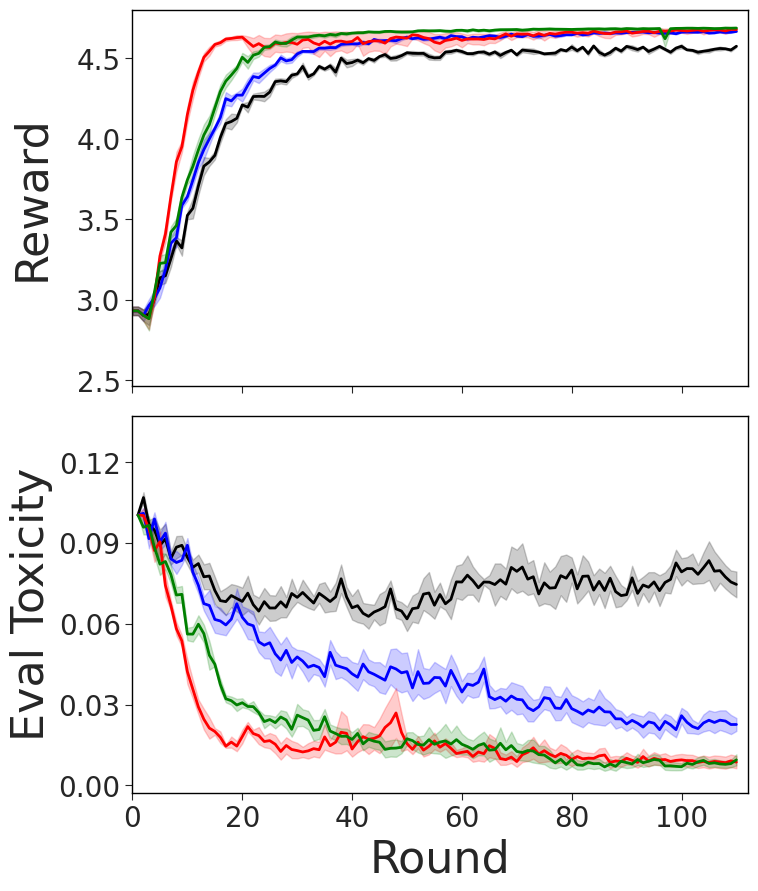


  self-ref / token-pg
    [reward] + FullTraining-LoRA: 5 seeds, final=4.5739
    [reward] + IIF-LoRA: 5 seeds, final=4.5790
    [reward] + LayerWiseSubset-LoRA: 5 seeds, final=4.5501
    [reward] + GlobalSubset-LoRA: 5 seeds, final=4.5477
    [eval_tox] + FullTraining-LoRA: 5 seeds, final=0.0746
    [eval_tox] + IIF-LoRA: 5 seeds, final=0.0671
    [eval_tox] + LayerWiseSubset-LoRA: 5 seeds, final=0.0744
    [eval_tox] + GlobalSubset-LoRA: 5 seeds, final=0.0762
    -> Saved: ./figures/self-ref_token-pg.pdf


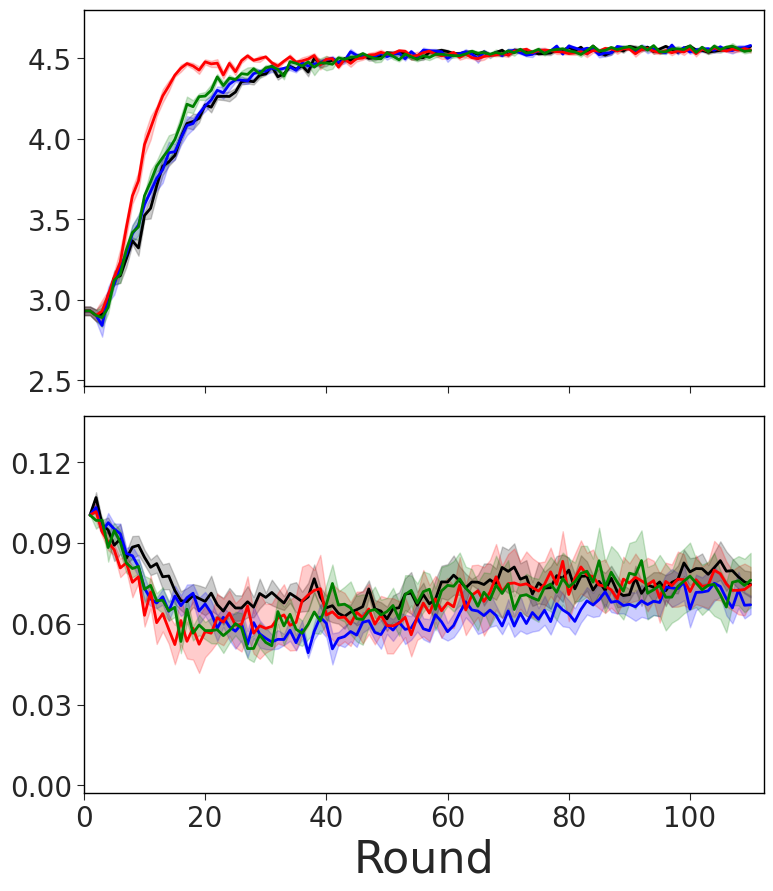


  self-ref / train-loss
    [reward] + FullTraining-LoRA: 5 seeds, final=4.5739
    [reward] + IIF-LoRA: 5 seeds, final=4.5574
    [reward] + LayerWiseSubset-LoRA: 5 seeds, final=4.5602
    [reward] + GlobalSubset-LoRA: 5 seeds, final=4.5370
    [eval_tox] + FullTraining-LoRA: 5 seeds, final=0.0746
    [eval_tox] + IIF-LoRA: 5 seeds, final=0.0715
    [eval_tox] + LayerWiseSubset-LoRA: 5 seeds, final=0.0496
    [eval_tox] + GlobalSubset-LoRA: 5 seeds, final=0.0520
    -> Saved: ./figures/self-ref_train-loss.pdf


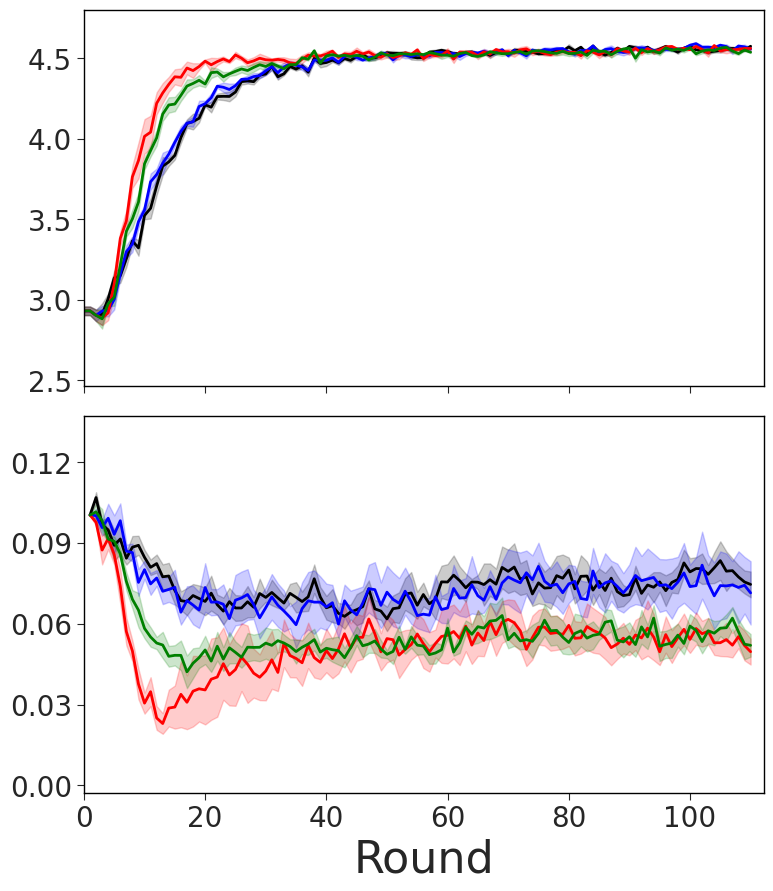


  held-out / reward
    [reward] + FullTraining-LoRA: 5 seeds, final=4.5739
    [reward] + TargetOnly-LoRA: 5 seeds, final=4.5749
    [reward] + IIF-LoRA: 5 seeds, final=4.6652
    [reward] + LayerWiseSubset-LoRA: 5 seeds, final=4.6613
    [reward] + GlobalSubset-LoRA: 5 seeds, final=4.6935
    [eval_tox] + FullTraining-LoRA: 5 seeds, final=0.0746
    [eval_tox] + TargetOnly-LoRA: 5 seeds, final=0.1154
    [eval_tox] + IIF-LoRA: 5 seeds, final=0.0169
    [eval_tox] + LayerWiseSubset-LoRA: 5 seeds, final=0.0072
    [eval_tox] + GlobalSubset-LoRA: 5 seeds, final=0.0089
    -> Saved: ./figures/held-out_reward.pdf


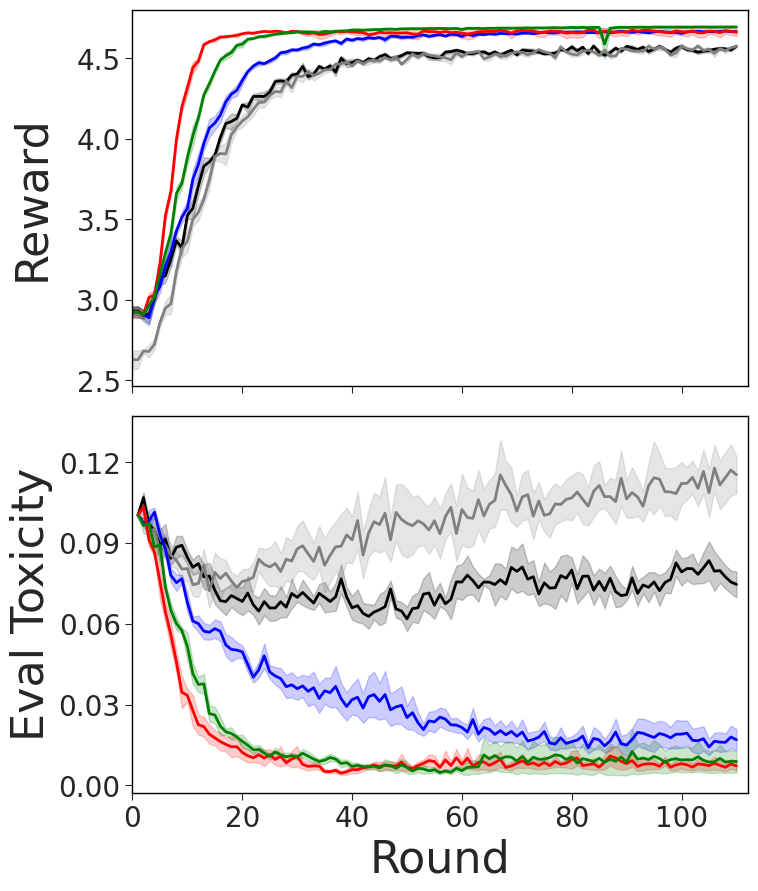


  held-out / token-pg
    [reward] + FullTraining-LoRA: 5 seeds, final=4.5739
    [reward] + TargetOnly-LoRA: 5 seeds, final=4.5749
    [reward] + IIF-LoRA: 5 seeds, final=4.5666
    [reward] + LayerWiseSubset-LoRA: 5 seeds, final=4.5840
    [reward] + GlobalSubset-LoRA: 5 seeds, final=4.5249
    [eval_tox] + FullTraining-LoRA: 5 seeds, final=0.0746
    [eval_tox] + TargetOnly-LoRA: 5 seeds, final=0.1154
    [eval_tox] + IIF-LoRA: 5 seeds, final=0.0624
    [eval_tox] + LayerWiseSubset-LoRA: 5 seeds, final=0.0814
    [eval_tox] + GlobalSubset-LoRA: 5 seeds, final=0.0511
    -> Saved: ./figures/held-out_token-pg.pdf


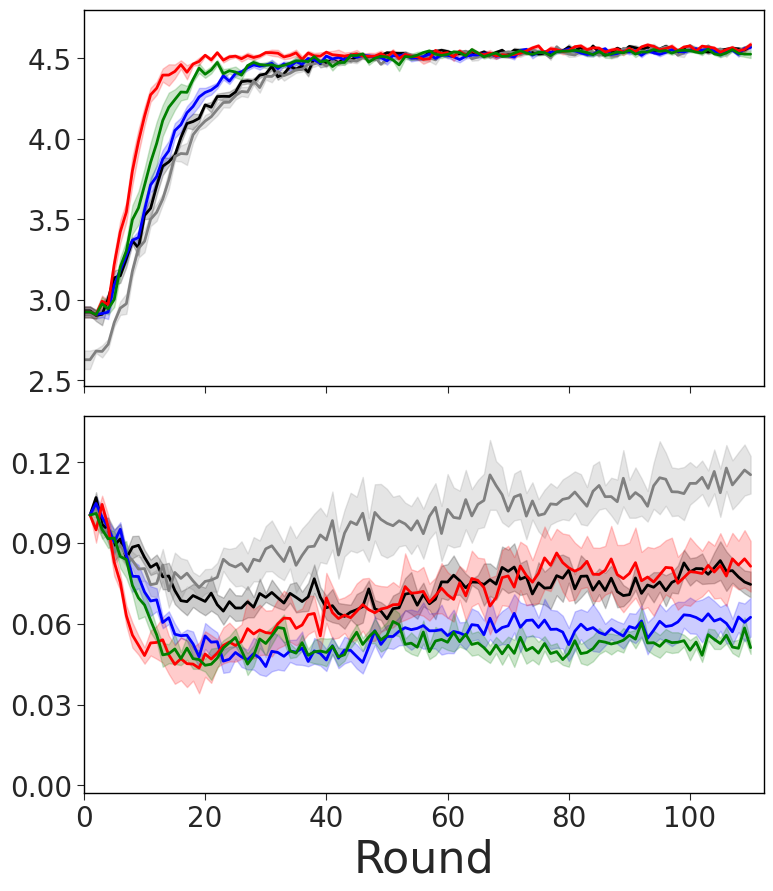


  held-out / train-loss
    [reward] + FullTraining-LoRA: 5 seeds, final=4.5739
    [reward] + TargetOnly-LoRA: 5 seeds, final=4.5749
    [reward] + IIF-LoRA: 5 seeds, final=4.5399
    [reward] + LayerWiseSubset-LoRA: 5 seeds, final=4.5712
    [reward] + GlobalSubset-LoRA: 5 seeds, final=4.5293
    [eval_tox] + FullTraining-LoRA: 5 seeds, final=0.0746
    [eval_tox] + TargetOnly-LoRA: 5 seeds, final=0.1154
    [eval_tox] + IIF-LoRA: 5 seeds, final=0.0665
    [eval_tox] + LayerWiseSubset-LoRA: 5 seeds, final=0.0833
    [eval_tox] + GlobalSubset-LoRA: 5 seeds, final=0.0766
    -> Saved: ./figures/held-out_train-loss.pdf


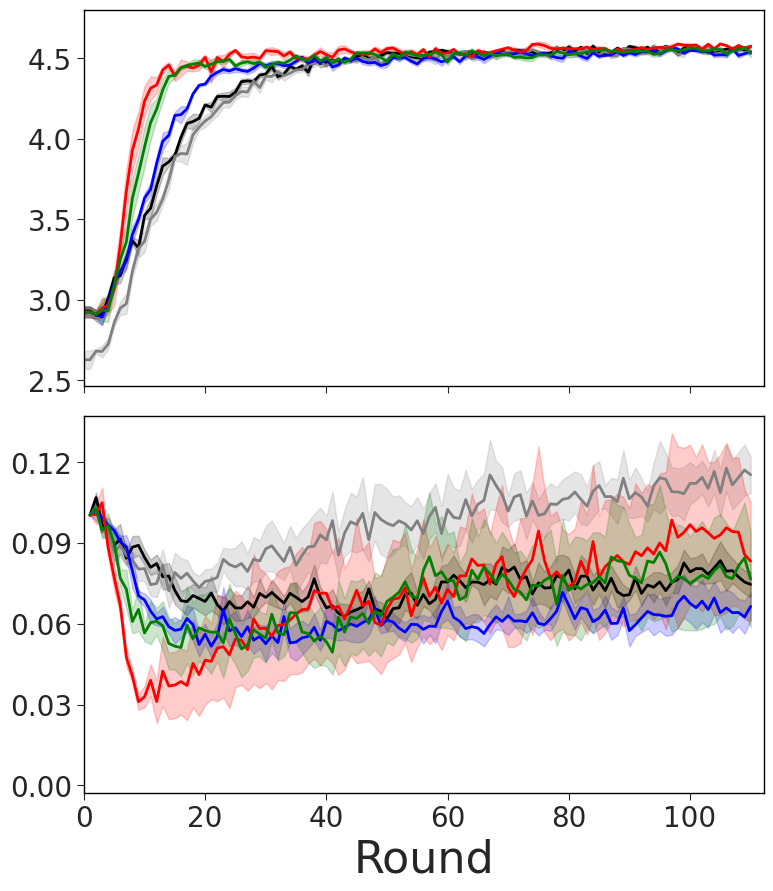


Saved legend: ./figures/legend.pdf


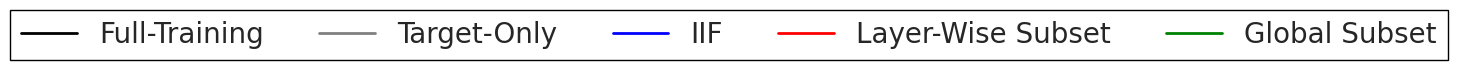

In [4]:
# Paper figures: combined Reward (top) + Eval Toxicity (bottom) per scenario, sharex
from matplotlib.ticker import MaxNLocator

max_step = None  # Set to None for all steps

PAPER_PLOTS = [
    {'key': 'reward', 'x': lambda d: d['steps'], 'y': lambda d: d['reward_mean_mean'],
     'std': lambda d: d['reward_mean_std']},
    {'key': 'eval_tox', 'x': lambda d: d['eval_toxicity_steps'], 'y': lambda d: d['eval_toxicity_mean'],
     'std': lambda d: d['eval_toxicity_std']},
]

# First pass: collect axis ranges + pre-compute shared y-ticks per metric.
# This guarantees every scenario uses identical y-limits AND identical tick positions,
# so when placed side-by-side in LaTeX the y-axes look exactly the same.
metric_ranges = {}  # key -> {'x_max', 'y_min', 'y_max', 'y_ticks'}
for pcfg in PAPER_PLOTS:
    x_vals, y_mins, y_maxs = [], [], []
    for sname, scfg in SCENARIOS.items():
        sdata = all_data[sname]
        for method_name in ALL_METHODS:
            if method_name not in sdata:
                continue
            data = sdata[method_name]
            x, mean, std = pcfg['x'](data), pcfg['y'](data), pcfg['std'](data)
            if x is None or len(x) == 0 or mean is None or len(mean) == 0:
                continue
            if max_step is not None:
                mask = x <= max_step
                x, mean = x[mask], mean[mask]
                std = std[mask] if std is not None and len(std) > 0 else None
            x_vals.append(x)
            if std is not None and len(std) > 0 and data['n_seeds'] > 1:
                y_mins.append((mean - std).min())
                y_maxs.append((mean + std).max())
            else:
                y_mins.append(mean.min())
                y_maxs.append(mean.max())
    if x_vals:
        y_pad = (max(y_maxs) - min(y_mins)) * 0.05
        y_min = min(y_mins) - y_pad
        y_max = max(y_maxs) + y_pad
        # Pre-compute the y-tick positions once so every scenario uses the same set.
        ticks = MaxNLocator(5).tick_values(y_min, y_max)
        ticks = ticks[(ticks >= y_min) & (ticks <= y_max)]
        metric_ranges[pcfg['key']] = {
            'x_max': max(v.max() for v in x_vals),
            'y_min': y_min,
            'y_max': y_max,
            'y_ticks': ticks,
        }

# Scenarios whose figures will be leftmost in their row (need y-axis labels)
LEFTMOST_SCENARIOS = {'self-ref / reward', 'held-out / reward'}

# Same figsize for every scenario, but a wider left margin on leftmost (room for the
# y-label) and a tighter left margin on the others. Saving without bbox_inches='tight'
# preserves figsize, so every PDF has identical outer dimensions while the leftmost
# plot area is smaller (the y-label "consumes" the difference).
#
# OTHER_LEFT must hold the widest y-tick label ("0.04" at fontsize 20 ≈ 0.48 inches
# of glyph width) PLUS tick mark length (5 pt ≈ 0.07") PLUS tick label pad
# (~3.5 pt ≈ 0.05") = ~0.60 inches total left of the axes spine. With figsize=8,
# the fraction must be at least 0.075; we use 0.12 to leave a comfortable cushion.
SHARED_RIGHT = 0.97
SHARED_TOP = 0.98
SHARED_BOTTOM = 0.11
SHARED_HSPACE = 0.08
LEFTMOST_LEFT = 0.20   # room for y-label + y-ticks
OTHER_LEFT = 0.12      # room for y-ticks only (must not clip "0.04" at fontsize 20)

# Second pass: one combined figure per scenario
for sname, scfg in SCENARIOS.items():
    sdata = all_data[sname]
    sname_safe = sname.replace(' / ', '_').replace(' ', '_')

    print(f"\n{'='*60}")
    print(f"  {sname}")
    print(f"{'='*60}")

    fig, axes = plt.subplots(2, 1, figsize=(8, 9), sharex=True)
    fig.patch.set_facecolor('white')

    for ax, pcfg in zip(axes, PAPER_PLOTS):
        ax.set_facecolor('white')

        has_data = False
        for method_name in ALL_METHODS:
            if method_name not in sdata:
                continue
            data = sdata[method_name]
            x, mean, std = pcfg['x'](data), pcfg['y'](data), pcfg['std'](data)
            if x is None or len(x) == 0 or mean is None or len(mean) == 0:
                continue
            if max_step is not None:
                mask = x <= max_step
                x, mean = x[mask], mean[mask]
                std = std[mask] if std is not None and len(std) > 0 else None

            color = METHOD_COLORS.get(method_name)
            display = LEGEND_NAMES.get(method_name, method_name)
            ax.plot(x, mean, linewidth=2, label=display, color=color)
            if std is not None and len(std) > 0 and data['n_seeds'] > 1:
                ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)
            has_data = True
            print(f"    [{pcfg['key']}] + {method_name}: {data['n_seeds']} seeds, final={mean[-1]:.4f}")

        # Y-axis label only on leftmost scenarios
        if sname in LEFTMOST_SCENARIOS:
            label = 'Reward' if pcfg['key'] == 'reward' else 'Eval Toxicity'
            ax.set_ylabel(label, fontsize=32)

        ax.grid(True, alpha=0.3, linewidth=0.5)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=20, direction='out', length=5)
        ax.xaxis.set_major_locator(MaxNLocator(6))
        if pcfg['key'] == 'eval_tox':
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))

        # Shared y-limits + identical y-tick positions across all scenarios
        if pcfg['key'] in metric_ranges:
            mr = metric_ranges[pcfg['key']]
            ax.set_xlim(left=0, right=mr['x_max'] * 1.02)
            ax.set_ylim(mr['y_min'], mr['y_max'])
            ax.set_yticks(mr['y_ticks'])

        if not has_data:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', fontsize=24, color='gray')

    # Single x-axis label at the bottom (sharex hides ticks on top automatically)
    axes[-1].set_xlabel('Round', fontsize=32)

    # Align y-axis labels horizontally across both subplots (only matters for leftmost scenarios)
    fig.align_ylabels(axes)

    # Pin axes position. Leftmost: more left margin for the y-label (plot area is smaller).
    # Others: tight left margin (plot area uses the freed-up space).
    left = LEFTMOST_LEFT if sname in LEFTMOST_SCENARIOS else OTHER_LEFT
    fig.subplots_adjust(left=left, right=SHARED_RIGHT, top=SHARED_TOP,
                        bottom=SHARED_BOTTOM, hspace=SHARED_HSPACE)

    filepath = os.path.join(save_dir, f"{sname_safe}.pdf")
    fig.savefig(filepath, format='pdf', facecolor='white')
    print(f"    -> Saved: {filepath}")
    plt.show()

# Save a standalone legend figure
legend_labels = [LEGEND_NAMES[m] for m in ALL_METHODS]
legend_colors = [METHOD_COLORS[m] for m in ALL_METHODS]

fig_leg, ax_leg = plt.subplots(figsize=(8, 0.5))
ax_leg.set_axis_off()
handles = [plt.Line2D([0], [0], color=c, linewidth=2) for c in legend_colors]
legend = fig_leg.legend(handles, legend_labels, loc='center', ncol=len(legend_labels),
                        fontsize=20, frameon=True, edgecolor='black', fancybox=False, framealpha=1.0)
legend.get_frame().set_facecolor('white')
fig_leg.patch.set_facecolor('white')
filepath = os.path.join(save_dir, 'legend.pdf')
fig_leg.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
print(f"\nSaved legend: {filepath}")
plt.show()

## All Scenarios: Comparison Grid + Summary Tables

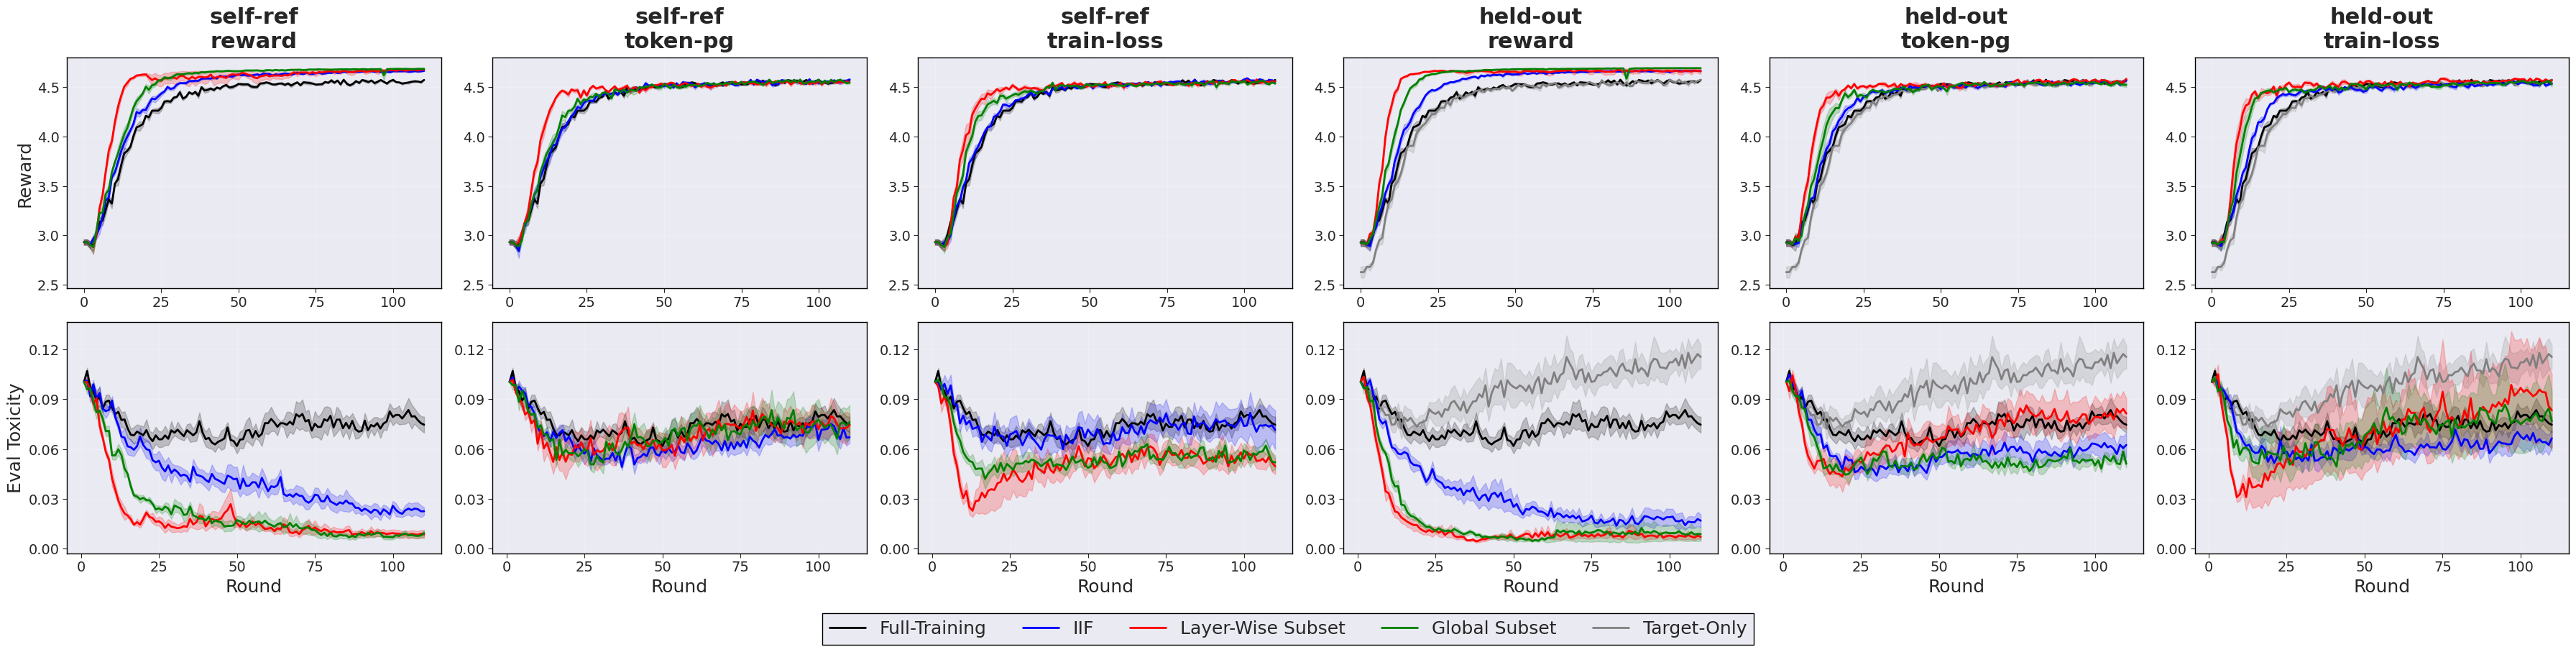


  self-ref / reward
Method               Seeds   Reward                 Batch Tox              Eval Tox              
-----------------------------------------------------------------------------------------------
FullTraining-LoRA    5       4.5739 +/- 0.0057      0.0687 +/- 0.0071      0.0746 +/- 0.0048     
IIF-LoRA             5       4.6659 +/- 0.0015      0.0176 +/- 0.0018      0.0226 +/- 0.0024     
LayerWiseSubset-LoRA 5       4.6776 +/- 0.0115      0.0086 +/- 0.0024      0.0086 +/- 0.0023     
GlobalSubset-LoRA    5       4.6869 +/- 0.0052      0.0104 +/- 0.0021      0.0094 +/- 0.0021     

  self-ref / token-pg
Method               Seeds   Reward                 Batch Tox              Eval Tox              
-----------------------------------------------------------------------------------------------
FullTraining-LoRA    5       4.5739 +/- 0.0057      0.0687 +/- 0.0071      0.0746 +/- 0.0048     
IIF-LoRA             5       4.5790 +/- 0.0026      0.0503 +/- 0.0056      0.0

In [5]:
# ============================================
# All-scenarios comparison grid (2 rows x N cols)
# ============================================
scenario_names = list(SCENARIOS.keys())
n_scenarios = len(scenario_names)

fig, axes = plt.subplots(2, n_scenarios, figsize=(6 * n_scenarios, 4.5 * 2), squeeze=False)
fig.patch.set_facecolor('white')

for col, sname in enumerate(scenario_names):
    sdata = all_data.get(sname, {})
    for method_name in ALL_METHODS:
        if method_name not in sdata:
            continue
        data = sdata[method_name]
        color = METHOD_COLORS.get(method_name)
        display = LEGEND_NAMES.get(method_name, method_name)

        x, mean, std = data['steps'], data['reward_mean_mean'], data['reward_mean_std']
        if max_step is not None:
            mask = x <= max_step
            x, mean, std = x[mask], mean[mask], std[mask]
        axes[0, col].plot(x, mean, linewidth=2, color=color, label=display)
        if data['n_seeds'] > 1:
            axes[0, col].fill_between(x, mean - std, mean + std, color=color, alpha=0.2)

        ex, emean, estd = data['eval_toxicity_steps'], data['eval_toxicity_mean'], data['eval_toxicity_std']
        if len(ex) > 0:
            if max_step is not None:
                emask = ex <= max_step
                ex, emean, estd = ex[emask], emean[emask], estd[emask]
            axes[1, col].plot(ex, emean, linewidth=2, color=color, label=display)
            if data['n_seeds'] > 1:
                axes[1, col].fill_between(ex, emean - estd, emean + estd, color=color, alpha=0.2)

    # Formatting
    if col == 0:
        axes[0, col].set_ylabel('Reward', fontsize=18)
        axes[1, col].set_ylabel('Eval Toxicity', fontsize=18)
    axes[0, col].set_title(sname.replace(' / ', '\n'), fontsize=22, fontweight='bold', pad=10)
    axes[1, col].set_xlabel('Round', fontsize=18)
    for row_idx in range(2):
        ax = axes[row_idx, col]
        ax.grid(True, alpha=0.3, linewidth=0.5)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=14, direction='out', length=4)
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    axes[1, col].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))

# Enforce shared axis limits per row (same metric across scenarios)
for row_idx in range(2):
    row_axes = [axes[row_idx, col] for col in range(n_scenarios)]
    all_xlims = [ax.get_xlim() for ax in row_axes]
    all_ylims = [ax.get_ylim() for ax in row_axes]
    shared_xlim = (min(l[0] for l in all_xlims), max(l[1] for l in all_xlims))
    shared_ylim = (min(l[0] for l in all_ylims), max(l[1] for l in all_ylims))
    for ax in row_axes:
        ax.set_xlim(shared_xlim)
        ax.set_ylim(shared_ylim)

# Shared legend at bottom (deduplicated)
handles, labels = [], []
for ax_row in axes:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
seen = {}
unique_handles, unique_labels = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = True
        unique_handles.append(h)
        unique_labels.append(l)

fig.legend(unique_handles, unique_labels, loc='lower center', ncol=len(unique_labels),
           fontsize=18, frameon=True, edgecolor='black', fancybox=False, framealpha=1.0,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


# ============================================
# Summary tables: per scenario + cross-scenario
# ============================================
for sname in scenario_names:
    sdata = all_data.get(sname, {})
    if not sdata:
        continue
    print(f"\n{'='*95}")
    print(f"  {sname}")
    print(f"{'='*95}")
    print(f"{'Method':<20} {'Seeds':<7} {'Reward':<22} {'Batch Tox':<22} {'Eval Tox':<22}")
    print("-" * 95)
    for name in ALL_METHODS:
        if name not in sdata:
            continue
        d = sdata[name]
        n = d['n_seeds']
        r = d['reward_mean_mean']
        rs = d['reward_mean_std']
        bt = d['batch_toxicity_mean']
        bts = d['batch_toxicity_std']
        et = d['eval_toxicity_mean']
        ets = d['eval_toxicity_std']
        r_str = f"{r[-1]:.4f} +/- {rs[-1]:.4f}" if n > 1 else f"{r[-1]:.4f}"
        bt_str = f"{bt[-1]:.4f} +/- {bts[-1]:.4f}" if n > 1 and len(bt) > 0 else f"{bt[-1]:.4f}" if len(bt) > 0 else "N/A"
        et_str = f"{et[-1]:.4f} +/- {ets[-1]:.4f}" if n > 1 and len(et) > 0 else f"{et[-1]:.4f}" if len(et) > 0 else "N/A"
        print(f"{name:<20} {n:<7} {r_str:<22} {bt_str:<22} {et_str:<22}")
    print("=" * 95)

# Cross-scenario comparison
print(f"\n{'='*130}")
print(f"Cross-Scenario: Final Reward / Eval Toxicity")
print(f"{'='*130}")
print(f"{'Method':<20}", end="")
for sname in scenario_names:
    short = sname.split(' / ')[1] if ' / ' in sname else sname
    print(f" {short:>12} / {'tox':>6} |", end="")
print()
print("-" * 130)
for method_name in ALL_METHODS:
    display = LEGEND_NAMES.get(method_name, method_name)
    print(f"{display:<20}", end="")
    for sname in scenario_names:
        sdata = all_data.get(sname, {})
        if method_name in sdata:
            d = sdata[method_name]
            r = d['reward_mean_mean'][-1] if len(d['reward_mean_mean']) > 0 else float('nan')
            t = d['eval_toxicity_mean'][-1] if len(d['eval_toxicity_mean']) > 0 else float('nan')
            print(f" {r:12.4f} / {t:6.4f} |", end="")
        else:
            print(f" {'N/A':>12} / {'N/A':>6} |", end="")
    print()
print("=" * 130)